# 05 - Regression: Predicting the Restaurant Rating (PuneBite Analyzer)

**Objective:** predict the rating itself (a number between 2.0 and 4.9) and understand which features push it up or down.
**Input:** `data/processed/restaurants_clean.csv`
**Output:** model comparison, interpreted coefficients, best model saved to `ml/models/`
**Syllabus link:** Unit V (Linear, Polynomial, Lasso, Ridge, Elastic Net regression; MSE, RMSE, R-squared); Unit IV (regularisation, overfitting, feature selection); Lab 6.

We use the same two scenarios as in notebook 04:
- **Scenario A (with votes):** describes existing restaurants.
- **Scenario B (no votes):** for a restaurant that has no reviews yet (used by the Opening Advisor).

Star-percentage columns and `spam_review_count` stay out of the inputs (data leakage).

In [1]:
import os, sys, json, time, warnings
sys.path.append(os.path.abspath(".."))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sklearn

from scipy import stats
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from ml import features as feat

pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

df = pd.read_csv("../data/processed/restaurants_clean.csv")
cols = list(df.columns)
amenity_cols = cols[cols.index("star1_pct") + 1 : cols.index("spam_review_count")]
rated = df[df["has_rating"]].copy().reset_index(drop=True)

y = rated["rating"]
print("Rated restaurants:", len(rated))
print(y.describe().round(2))

Rated restaurants: 7669
count    7669.00
mean        3.44
std         0.42
min         2.00
25%         3.10
50%         3.40
75%         3.70
max         4.90
Name: rating, dtype: float64


## 1. Data preparation
Same features as the classifier (`ml/features.py`): price, counts, payment flags, restaurant type, locality, top cuisines and common amenities. Categorical columns are one-hot encoded and numbers are scaled **inside** each pipeline, so the test set never influences the preprocessing.

In [2]:
spec = feat.fit_feature_spec(df, amenity_cols)
X_votes, info_votes = feat.make_features(rated, spec, with_votes=True)
X_novotes, info_novotes = feat.make_features(rated, spec, with_votes=False)

idx_train, idx_test = train_test_split(np.arange(len(rated)), test_size=0.2, random_state=RANDOM_STATE)
SCEN = {"A: with votes": (X_votes, info_votes), "B: no votes": (X_novotes, info_novotes)}
splits = {k: (X.iloc[idx_train], X.iloc[idx_test]) for k, (X, _) in SCEN.items()}
y_train, y_test = y.iloc[idx_train], y.iloc[idx_test]
print("Train:", len(idx_train), "| Test:", len(idx_test), "| Features A/B:", X_votes.shape[1], "/", X_novotes.shape[1])

Train: 6135 | Test: 1534 | Features A/B: 53 / 52


## 2. Metrics used

- **MSE** (mean squared error): average of squared errors; punishes big mistakes.
- **RMSE**: square root of MSE, in rating points (easy to explain: "typically off by about this much").
- **MAE**: average absolute error.
- **R-squared**: share of the variation in ratings the model explains (0 = no better than guessing the average, 1 = perfect).

The baseline always predicts the training average.

In [3]:
def evaluate(model, X, y_true):
    pred = model.predict(X)
    mse = mean_squared_error(y_true, pred)
    return {"MSE": mse, "RMSE": np.sqrt(mse), "MAE": mean_absolute_error(y_true, pred), "R2": r2_score(y_true, pred)}

def make_pipeline(model, info, poly_degree=None):
    num_steps = [("scale", StandardScaler())]
    if poly_degree:
        num_steps.append(("poly", PolynomialFeatures(degree=poly_degree, include_bias=False)))
    pre = ColumnTransformer([
        ("num", Pipeline(num_steps), info["numeric"]),
        ("cat", OneHotEncoder(handle_unknown="ignore"), info["categorical"]),
        ("bin", "passthrough", info["binary"]),
    ])
    return Pipeline([("pre", pre), ("model", model)])

base = DummyRegressor(strategy="mean").fit(splits["B: no votes"][0], y_train)
print("Baseline (always predict the mean):", {k: round(v, 3) for k, v in evaluate(base, splits["B: no votes"][1], y_test).items()})

Baseline (always predict the mean): {'MSE': 0.181, 'RMSE': np.float64(0.426), 'MAE': 0.341, 'R2': -0.002}


## 3. Plain Linear Regression (the Lab 6 model)

In [4]:
lin = {}
for scen, (X_tr, X_te) in splits.items():
    lin[scen] = make_pipeline(LinearRegression(), SCEN[scen][1]).fit(X_tr, y_train)
    print(scen, "| train:", {k: round(v, 3) for k, v in evaluate(lin[scen], X_tr, y_train).items()})
    print(" " * len(scen), "| test: ", {k: round(v, 3) for k, v in evaluate(lin[scen], X_te, y_test).items()})

A: with votes | train: {'MSE': 0.073, 'RMSE': np.float64(0.271), 'MAE': 0.19, 'R2': 0.57}
              | test:  {'MSE': 0.081, 'RMSE': np.float64(0.285), 'MAE': 0.198, 'R2': 0.551}
B: no votes | train: {'MSE': 0.122, 'RMSE': np.float64(0.349), 'MAE': 0.275, 'R2': 0.284}
            | test:  {'MSE': 0.13, 'RMSE': np.float64(0.361), 'MAE': 0.284, 'R2': 0.279}


## 4. Regularised models: Ridge, Lasso, Elastic Net

With many features that overlap (for example amenities that tend to come together), plain linear regression can give unstable coefficients. Regularisation adds a penalty on large coefficients:

- **Ridge (L2):** shrinks all coefficients smoothly.
- **Lasso (L1):** can shrink some coefficients to exactly zero, which is built-in feature selection.
- **Elastic Net:** a mix of both.

The penalty strength `alpha` is chosen by 5-fold cross-validation on the training data only.

In [5]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

GRIDS = {
    "Ridge": (Ridge(), {"model__alpha": np.logspace(-2, 3, 11)}),
    "Lasso": (Lasso(max_iter=20000), {"model__alpha": np.logspace(-4, -1, 10)}),
    "Elastic Net": (ElasticNet(max_iter=20000), {"model__alpha": np.logspace(-4, -1, 8), "model__l1_ratio": [0.2, 0.5, 0.8]}),
}

searches = {}
t0 = time.time()
for scen, (X_tr, _) in splits.items():
    for name, (model, grid) in GRIDS.items():
        gs = GridSearchCV(make_pipeline(model, SCEN[scen][1]), grid, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=1)
        searches[(scen, name)] = gs.fit(X_tr, y_train)
print(f"Tuning done in {time.time() - t0:.0f}s")
for (scen, name), gs in searches.items():
    print(f"{scen:14s} {name:12s} best params: { {k.replace('model__', ''): round(v, 5) for k, v in gs.best_params_.items()} }  CV RMSE = {-gs.best_score_:.3f}")

Tuning done in 29s
A: with votes  Ridge        best params: {'alpha': np.float64(31.62278)}  CV RMSE = 0.275
A: with votes  Lasso        best params: {'alpha': np.float64(0.00046)}  CV RMSE = 0.275
A: with votes  Elastic Net  best params: {'alpha': np.float64(0.00193), 'l1_ratio': 0.2}  CV RMSE = 0.275
B: no votes    Ridge        best params: {'alpha': np.float64(31.62278)}  CV RMSE = 0.356
B: no votes    Lasso        best params: {'alpha': np.float64(0.00046)}  CV RMSE = 0.356
B: no votes    Elastic Net  best params: {'alpha': np.float64(0.00193), 'l1_ratio': 0.2}  CV RMSE = 0.356


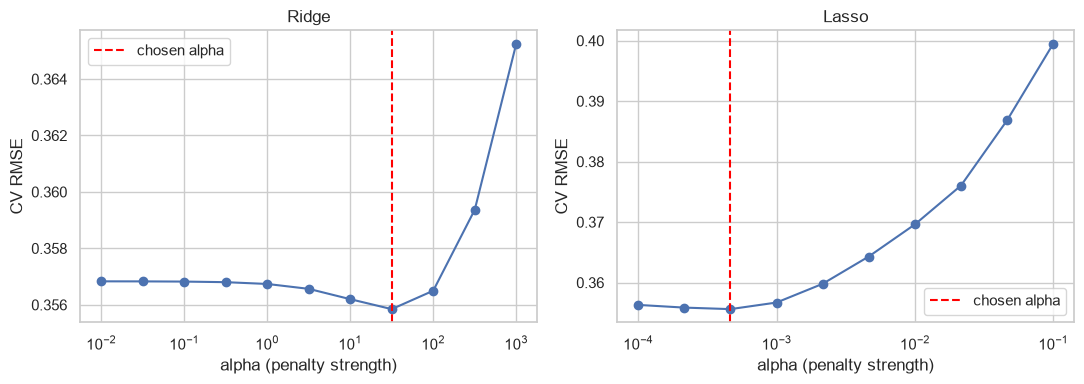

In [6]:
# How the penalty strength affects cross-validated error (Scenario B)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, name in zip(ax, ["Ridge", "Lasso"]):
    res = searches[("B: no votes", name)].cv_results_
    alphas = [p["model__alpha"] for p in res["params"]]
    a.semilogx(alphas, -res["mean_test_score"], "o-")
    a.axvline(searches[("B: no votes", name)].best_params_["model__alpha"], color="red", linestyle="--", label="chosen alpha")
    a.set_xlabel("alpha (penalty strength)"); a.set_ylabel("CV RMSE"); a.set_title(name); a.legend()
plt.tight_layout(); plt.show()

## 5. Polynomial Regression

Polynomial features let a linear model capture curves and interactions (for example price x number of amenities). We expand only the numeric inputs to degree 2 and add Ridge regularisation to keep it stable. Degree 3 and above would explode the number of features and overfit.

In [7]:
poly_search = {}
for scen, (X_tr, _) in splits.items():
    gs = GridSearchCV(make_pipeline(Ridge(), SCEN[scen][1], poly_degree=2), {"model__alpha": np.logspace(-1, 3, 9)},
                      cv=cv, scoring="neg_root_mean_squared_error", n_jobs=1)
    poly_search[scen] = gs.fit(X_tr, y_train)
    print(f"{scen:14s} Polynomial(2)+Ridge best alpha = {gs.best_params_['model__alpha']:.3g}, CV RMSE = {-gs.best_score_:.3f}")

A: with votes  Polynomial(2)+Ridge best alpha = 100, CV RMSE = 0.275
B: no votes    Polynomial(2)+Ridge best alpha = 31.6, CV RMSE = 0.356


## 6. Test-set comparison

Every model is scored once on the untouched test set. Random Forest is added as a non-linear reference.

In [8]:
rows = []
final_models = {}
for scen, (X_tr, X_te) in splits.items():
    info = SCEN[scen][1]
    candidates = {
        "Baseline (mean)": DummyRegressor(strategy="mean").fit(X_tr, y_train),
        "Linear": lin[scen],
        "Ridge": searches[(scen, "Ridge")].best_estimator_,
        "Lasso": searches[(scen, "Lasso")].best_estimator_,
        "Elastic Net": searches[(scen, "Elastic Net")].best_estimator_,
        "Polynomial (deg 2) + Ridge": poly_search[scen].best_estimator_,
        "Random Forest (reference)": make_pipeline(
            RandomForestRegressor(n_estimators=300, min_samples_leaf=3, n_jobs=-1, random_state=RANDOM_STATE), info).fit(X_tr, y_train),
    }
    for name, m in candidates.items():
        final_models[(scen, name)] = m
        rows.append({"scenario": scen, "model": name, **evaluate(m, X_te, y_test)})
results = pd.DataFrame(rows)

for scen in SCEN:
    print("\n" + scen)
    display(results[results.scenario == scen].drop(columns="scenario").set_index("model").sort_values("RMSE").round(3))


A: with votes


,MSE,RMSE,MAE,R2
model,,,,
Random Forest (reference),0.079,0.281,0.195,0.564
Polynomial (deg 2) + Ridge,0.080,0.284,0.196,0.555
Ridge,0.081,0.285,0.198,0.552
Elastic Net,0.081,0.285,0.198,0.551
Linear,0.081,0.285,0.198,0.551
Lasso,0.081,0.285,0.198,0.551
Baseline (mean),0.181,0.426,0.341,-0.002



B: no votes


,MSE,RMSE,MAE,R2
model,,,,
Polynomial (deg 2) + Ridge,0.129,0.360,0.283,0.284
Ridge,0.130,0.360,0.283,0.284
Elastic Net,0.130,0.360,0.283,0.283
Lasso,0.130,0.360,0.283,0.283
Linear,0.130,0.361,0.284,0.279
Random Forest (reference),0.131,0.362,0.286,0.276
Baseline (mean),0.181,0.426,0.341,-0.002


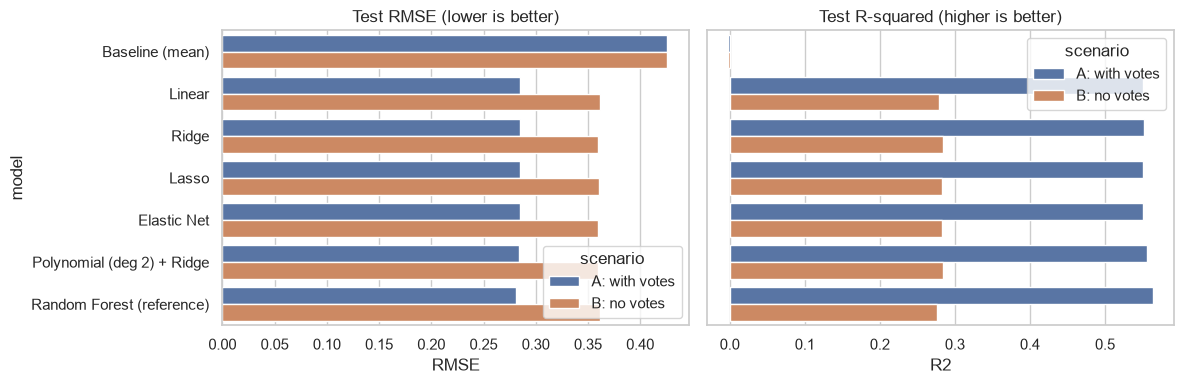

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=results, y="model", x="RMSE", hue="scenario", ax=ax[0]); ax[0].set_title("Test RMSE (lower is better)")
sns.barplot(data=results, y="model", x="R2", hue="scenario", ax=ax[1]); ax[1].set_title("Test R-squared (higher is better)")
ax[1].set_ylabel(""); ax[1].set_yticklabels([])
plt.tight_layout(); plt.show()

## 7. Which features matter? (Lasso coefficients, Scenario B)

All numeric inputs are standardised, so coefficients are comparable: a positive number means the feature goes with a higher rating, a negative number with a lower rating, **holding the others constant**. Features Lasso set to exactly zero were dropped by the model.

Lasso kept 68 of 95 features (set 27 to zero)


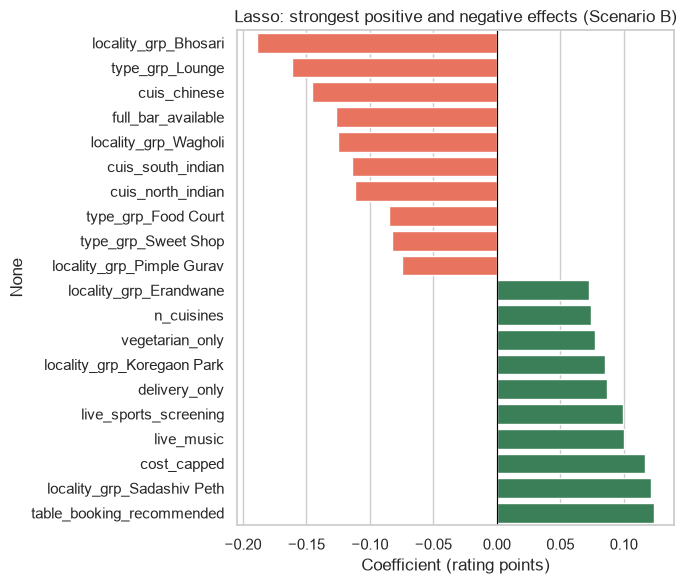

In [10]:
lasso_B = final_models[("B: no votes", "Lasso")]
names = lasso_B.named_steps["pre"].get_feature_names_out()
coef = pd.Series(lasso_B.named_steps["model"].coef_, index=[n.split("__", 1)[1] for n in names])

print(f"Lasso kept {(coef != 0).sum()} of {len(coef)} features (set {(coef == 0).sum()} to zero)")
top = pd.concat([coef.sort_values().head(10), coef.sort_values().tail(10)])
plt.figure(figsize=(7, 6))
sns.barplot(x=top.values, y=top.index, palette=["tomato" if v < 0 else "seagreen" for v in top.values])
plt.axvline(0, color="black", linewidth=0.8); plt.title("Lasso: strongest positive and negative effects (Scenario B)")
plt.xlabel("Coefficient (rating points)"); plt.tight_layout(); plt.show()

In [11]:
# Same view for Scenario A: how much does votes change the picture?
lasso_A = final_models[("A: with votes", "Lasso")]
coef_A = pd.Series(lasso_A.named_steps["model"].coef_,
                   index=[n.split("__", 1)[1] for n in lasso_A.named_steps["pre"].get_feature_names_out()])
coef_A.reindex(coef_A.abs().sort_values(ascending=False).index).head(8).round(3)

log_votes               0.282
mall_parking           -0.111
cuis_chinese           -0.095
locality_grp_Bavdhan   -0.086
free_wifi               0.080
no_alcohol_available   -0.076
cuis_north_indian      -0.065
locality_grp_Bhosari   -0.064
dtype: float64

## 8. Residual analysis (are the model's mistakes reasonable?)

A residual is *actual minus predicted*. For a good linear model the residuals should be centred on zero, roughly bell-shaped, and show no pattern against the prediction.

Best linear-family model for Scenario B: Polynomial (deg 2) + Ridge


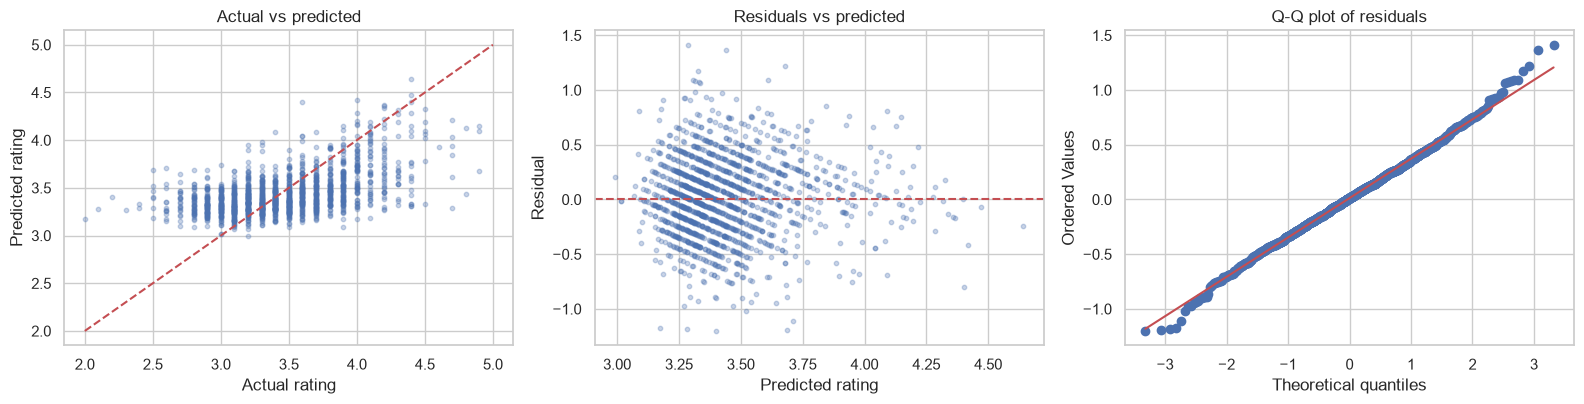

Mean residual: 0.013  |  Residual std: 0.360  |  skew: 0.07


In [12]:
best_B_name = results[(results.scenario == "B: no votes") & (~results.model.str.contains("reference|Baseline"))].sort_values("RMSE").iloc[0]["model"]
best_B = final_models[("B: no votes", best_B_name)]
X_te_B = splits["B: no votes"][1]
pred = best_B.predict(X_te_B)
resid = y_test.values - pred
print("Best linear-family model for Scenario B:", best_B_name)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].scatter(y_test, pred, alpha=0.3, s=10); ax[0].plot([2, 5], [2, 5], "r--")
ax[0].set_xlabel("Actual rating"); ax[0].set_ylabel("Predicted rating"); ax[0].set_title("Actual vs predicted")
ax[1].scatter(pred, resid, alpha=0.3, s=10); ax[1].axhline(0, color="r", linestyle="--")
ax[1].set_xlabel("Predicted rating"); ax[1].set_ylabel("Residual"); ax[1].set_title("Residuals vs predicted")
stats.probplot(resid, dist="norm", plot=ax[2]); ax[2].set_title("Q-Q plot of residuals")
plt.tight_layout(); plt.show()
print(f"Mean residual: {resid.mean():.3f}  |  Residual std: {resid.std():.3f}  |  skew: {stats.skew(resid):.2f}")

In [13]:
# Where does the model make bigger mistakes?
err = pd.DataFrame({"actual": y_test.values, "pred": pred, "abs_err": np.abs(resid), "votes": rated.loc[idx_test, "votes"].values})
err["actual_band"] = pd.cut(err["actual"], [1.9, 3.0, 3.5, 4.0, 5.0], labels=["<=3.0", "3.0-3.5", "3.5-4.0", ">4.0"])
err["votes_band"] = pd.cut(err["votes"], [-1, 9, 49, 499, 100000], labels=["0-9", "10-49", "50-499", "500+"])
display(err.groupby("actual_band", observed=True).agg(n=("actual", "size"), avg_actual=("actual", "mean"), avg_pred=("pred", "mean"), mae=("abs_err", "mean")).round(2))
display(err.groupby("votes_band", observed=True).agg(n=("actual", "size"), mae=("abs_err", "mean")).round(2))

,n,avg_actual,avg_pred,mae
actual_band,,,,
<=3.0,262,2.86,3.33,0.47
3.0-3.5,689,3.30,3.37,0.16
3.5-4.0,450,3.77,3.51,0.29
>4.0,133,4.28,3.76,0.53


,n,mae
votes_band,,
0-9,319,0.26
10-49,574,0.23
50-499,527,0.33
500+,114,0.40


## 9. Save the best Scenario B regressor for the API

In [14]:
os.makedirs("../ml/models", exist_ok=True)
save_name = results[(results.scenario == "B: no votes") & (~results.model.str.contains("Baseline"))].sort_values("RMSE").iloc[0]["model"]
save_model = final_models[("B: no votes", save_name)]
row = results[(results.scenario == "B: no votes") & (results.model == save_name)].iloc[0]

joblib.dump(save_model, "../ml/models/rating_regressor.joblib")
meta = {
    "model": save_name, "scenario": "B: no votes", "target": "rating",
    "feature_spec": spec, "feature_info": info_novotes,
    "test_rmse": float(row["RMSE"]), "test_r2": float(row["R2"]), "test_mae": float(row["MAE"]),
    "n_train": int(len(idx_train)), "sklearn_version": sklearn.__version__,
}
with open("../ml/models/rating_regressor_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print("Saved:", save_name, "| test RMSE", round(meta["test_rmse"], 3), "| R2", round(meta["test_r2"], 3))

Saved: Polynomial (deg 2) + Ridge | test RMSE 0.36 | R2 0.284


## 10. Summary and findings

### Test-set results

| Scenario | Best model | RMSE | MAE | R-squared | Baseline RMSE |
|---|---|---|---|---|---|
| A: with votes | Random Forest (reference) / Polynomial+Ridge | about 0.28 | about 0.20 | about 0.55 | 0.43 |
| B: no votes | Polynomial (deg 2) + Ridge | about 0.36 | about 0.28 | about 0.28 | 0.43 |

(Check the exact figures against your own output; they should match closely because the random seed is fixed.)

### Key findings

1. **Votes explain a lot.** With votes the models explain about 55% of the variation in ratings; without votes only about 28%. In Scenario A, `log_votes` is by far the largest coefficient (about +0.28 rating points per standard deviation).
2. **A new restaurant's rating can be predicted only roughly.** In Scenario B the typical error is about 0.28 rating points (MAE), versus 0.34 for just guessing the average. That is an improvement, but not a precise forecast, because food quality and service are not in the data.
3. **Regularisation barely changed the scores.** Linear, Ridge, Lasso, and Elastic Net are almost identical. With about 6,000 training rows and about 50 features, ordinary regression is already stable, so there is little overfitting to fix. This is a legitimate result, not a mistake. Lasso still earns its place as a feature-selection tool: it set 27 of 95 encoded features to exactly zero.
4. **Polynomial features helped only slightly**, and Random Forest did no better than the linear models here. That suggests the rating relationships are mostly additive, and the simple linear family is enough. The simpler Ridge model is almost as good as Polynomial+Ridge, so either is defensible; mention the trade-off between accuracy and simplicity in your viva.
5. **Regression to the mean in the residuals.** The model over-predicts the weakest restaurants (actual about 2.9, predicted about 3.3) and under-predicts the best ones (actual about 4.3, predicted about 3.8). It is safest in the middle of the range. Residuals are centred on zero and roughly bell-shaped, so the linear assumptions are reasonable.
6. **Direction of effects (Scenario B, Lasso):** see the coefficient chart for the strongest positive and negative features. As always, these are associations with other variables held constant, not proven causes.

### Link to classification (notebook 04)
Regression says how *high* the rating is likely to be; classification says whether it will pass 4.0. They agree on what matters (price, votes, locality, cuisine mix) and on the main limit: restaurant-level features alone cannot capture quality.

**Next:** `06_feature_selection_pca.ipynb` (feature selection and PCA on the 86 amenity columns).